In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image
import os

In [ ]:
work_dir = '/content/drive/MyDrive/Estudos/Mestrado/Métodos_estatísticos/LE2_Métodos_estatísticos'
input_csv = work_dir + '/servico_publico_dados_corrigido.csv'
output_excel = work_dir + '/questao_20/questao_20_le2.xlsx'

os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

In [ ]:
df = pd.read_csv(input_csv)
df.head()

,Região,Área,Ocupação,Opinião,Renda,Idade
0,Dalmácia,Educação,Funcionário público,Indiferente,1.89,29
1,Dalmácia,Infraestrutura,Assalariado/Autônomo,Indiferente,1.63,46
2,Catamarca,Educação,Funcionário público,Insatisfatório,4.50,37
3,Nortúmbria,Infraestrutura,Aposentado,Excelente,1.17,18
4,Querétaro,Infraestrutura,Empresário,Indiferente,2.84,38


## **Questão 20** - Realize as análises sugeridas e apresente as conclusões, JUSTIFICANDO-AS.

# **Opinião média (tendência central) por região**


In [ ]:
map_op = {
    'Péssimo': 1,
    'Insatisfatório': 2,
    'Indiferente': 3,
    'Satisfatório': 4,
    'Excelente': 5
}
df['Op_num'] = df['Opinião'].map(map_op)

In [ ]:
# Cálculo de média e mediana por região
resumo_regiao = df.groupby('Região')['Op_num'] \
                  .agg(['mean','median']) \
                  .rename(columns={'mean':'Média','median':'Mediana'}) \
                  .round(2)

In [ ]:
resumo_regiao

,Média,Mediana
Região,,
Aquitânia,1.02,1.0
Catamarca,1.57,1.0
Dalmácia,3.09,3.0
Nortúmbria,4.47,5.0
Querétaro,2.30,2.0


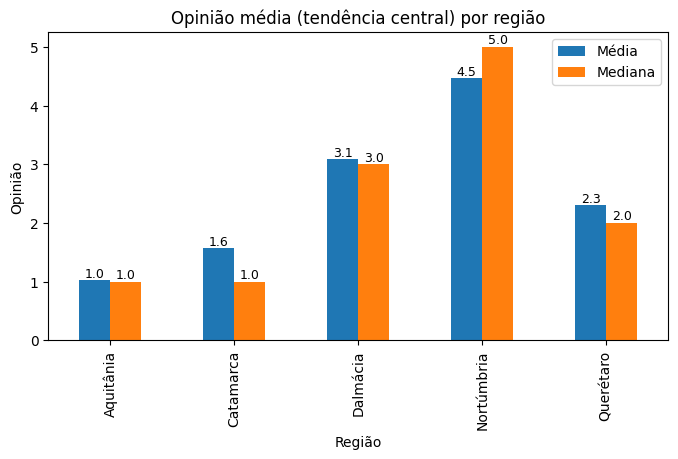

In [ ]:
ax = resumo_regiao.plot(kind='bar', figsize=(8, 4))
ax.set_title('Opinião média (tendência central) por região')
ax.set_ylabel('Opinião')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=9)

# ***Opinião central por faixa de idade em cada região***

In [ ]:
bins = [0, 30, 50, df['Idade'].max()]
labels = ['< 30 anos', '30–50 anos', '> 50 anos']
df['Faixa_Idade'] = pd.cut(df['Idade'], bins=bins, labels=labels, right=False)

In [ ]:
mediana_regiao_idade = (
    df
    .groupby(['Região', 'Faixa_Idade'])['Op_num']
    .median()
    .unstack()
)

<ipython-input-39-238ebe98c791>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Região', 'Faixa_Idade'])['Op_num']


In [ ]:
mediana_regiao_idade

Faixa_Idade,< 30 anos,30–50 anos,> 50 anos
Região,,,
Aquitânia,1.0,1.0,1.0
Catamarca,2.0,1.0,1.0
Dalmácia,3.0,3.0,3.0
Nortúmbria,5.0,4.0,5.0
Querétaro,3.0,2.0,2.0


Text(0, 0.5, 'Opinião')

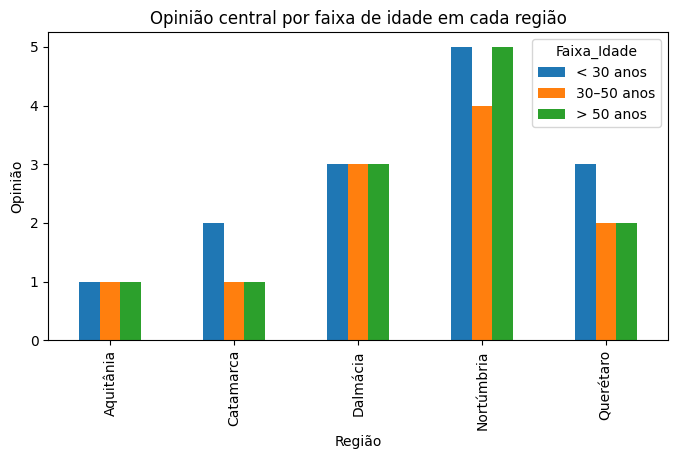

In [ ]:
ax = mediana_regiao_idade.plot(kind='bar', figsize=(8, 4))
ax.set_title('Opinião central por faixa de idade em cada região')
ax.set_ylabel('Opinião')

# ***Opinião central por área que o eleitor considera mais importante em cada região***

In [ ]:
mediana_regiao_area= (
    df
    .groupby(['Região', 'Área'])['Op_num']
    .median()
    .unstack()
)

In [ ]:
mediana_regiao_area

Área,Educação,Infraestrutura,Saúde pública,Segurança pública
Região,,,,
Aquitânia,1.0,1.0,1.0,1.0
Catamarca,2.0,2.0,1.0,1.0
Dalmácia,3.0,3.0,3.0,3.0
Nortúmbria,4.0,5.0,4.0,4.0
Querétaro,3.0,3.0,2.0,2.0


Text(0, 0.5, 'Opinião')

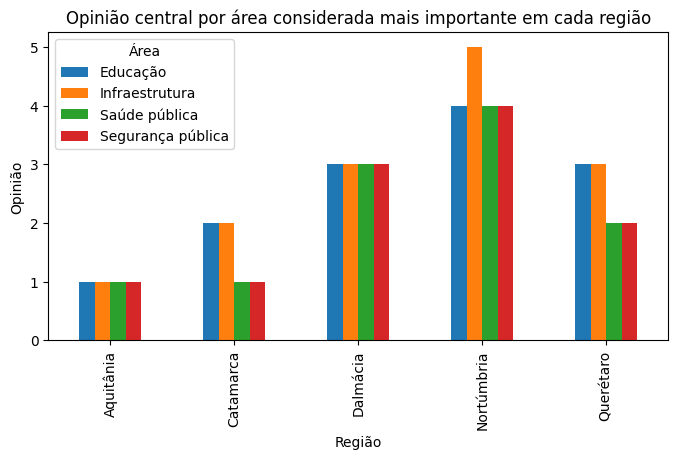

In [ ]:
ax = mediana_regiao_area.plot(kind='bar', figsize=(8, 4))
ax.set_title('Opinião central por área considerada mais importante em cada região')
ax.set_ylabel('Opinião')